# Introduction to Deep Learning with PyTorch Part II

**Vanessa Gómez Verdejo,  Pablo Martínez Olmos, Alejandro Lancho Serrano, Emilio Parrado Hernández**

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='http://www.tsc.uc3m.es/~emipar/BBVA/INTRO/img/logo_uc3m_foot.jpg' width=400 />


## Recap from Part I

In the first session, we introduced the **fundamentals of PyTorch**:

- Tensor operations and the automatic differentiation engine (`autograd`)  
- The implementation and training of **binary** and **multiclass logistic regression** models  
- Loss functions, gradient computation, and parameter updates using **stochastic gradient descent**  

By the end of Part I, we could already train a multiclass classifier for MNIST digits using a single linear layer.

## Learning Objectives — Part II

In this session, we will take the **next step**: building and training deeper models, while improving the way we organize and monitor our code.

Specifically, you will learn to:

- **Implement and train a Multi-Layer Perceptron (MLP)** in plain PyTorch  
- **Structure your workflow** using *PyTorch Lightning* for clean and scalable code  
- **Track experiments automatically** using *MLflow* (metrics, parameters, and artifacts)

We’ll reuse the same **MNIST dataset**, but move from manual loops to a more professional training pipeline.

In [1]:
# --- Reused from Part I (no new material): data loaders + simple models ---
# This cell redefines the MNIST loaders and baseline models (MLP, CNN)
# so that Part II runs independently even if you start here.

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Reproducibility
torch.manual_seed(1)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- MNIST dataset & loaders ----------
def get_mnist_loaders(batch_size=64, val_ratio=0.1, root_dir="./data"):
    """Create train/val/test loaders for MNIST."""
    transform = transforms.ToTensor()

    full_train = datasets.MNIST(root=root_dir, train=True,  download=True, transform=transform)
    test_set   = datasets.MNIST(root=root_dir, train=False, download=True, transform=transform)

    num_train = len(full_train)
    val_size  = int(val_ratio * num_train)
    train_size = num_train - val_size

    train_set, val_set = random_split(full_train, [train_size, val_size])

    pin = torch.cuda.is_available()
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=pin)
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=pin)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=pin)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = get_mnist_loaders()

# Implementing a Multilayer Perceptron



<img align="center" src="http://www.tsc.uc3m.es/~vanessa/Figs_notebooks/BBVA/GenAI/S1_Fig_7.png" width=80%>




The hidden layer can use the logistic sigmoid as activation function, but the most common activation is the ReLU:

$$
\mathrm{ReLU}(z) = \max(0, z)
$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

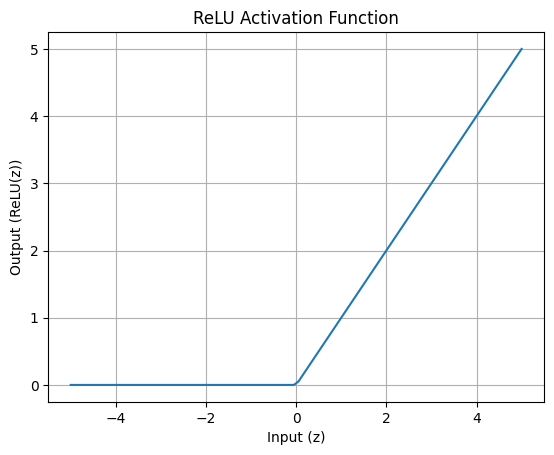

In [3]:
# Plot the ReLU activation function
x = np.linspace(-5, 5, 100)
y = np.maximum(0, x)

plt.plot(x, y)
plt.title('ReLU Activation Function')
plt.xlabel('Input (z)')
plt.ylabel('Output (ReLU(z))')
plt.grid(True)
plt.show()

**Note.** If we want a nonlinear classifier, we need a nonlinear activation function.  
Without an activation, stacking linear layers is still linear overall.

Let's implement our MultiLayer Perceptron

In [4]:
class PyTorchMLP(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()

        self.all_layers = torch.nn.Sequential(
            # 1st hidden layer
            torch.nn.Linear(num_features, 50),
            torch.nn.ReLU(),
            # 2nd hidden layer
            torch.nn.Linear(50, 25),
            torch.nn.ReLU(),
            # output layer
            torch.nn.Linear(25, num_classes),
        )

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        logits = self.all_layers(x)
        return logits

In [5]:
@torch.no_grad()
def compute_accuracy(model, dataloader, device=None):
    """Multiclass accuracy over a whole dataloader."""
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    correct = 0
    total = 0
    for features, labels in dataloader:
        features = features.to(device)
        labels = labels.to(device)
        logits = model(features)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return (correct / total) if total > 0 else 0.0

The training loop

In [6]:
import torch.nn.functional as F

torch.manual_seed(1)
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = PyTorchMLP(num_features=784, num_classes=10).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

num_epochs = 10

loss_list = []
train_acc_list, val_acc_list = [], []

for epoch in range(num_epochs):

    model.train()
    for batch_idx, (features, labels) in enumerate(train_loader):
        # Send data to device
        features, labels = features.to(device), labels.to(device)

        # Forward
        logits = model(features)
        loss = F.cross_entropy(logits, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if not batch_idx % 250:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
                f" | Train Loss: {loss:.2f}"
            )
        loss_list.append(loss.item())

    # End-of-epoch evaluation
    train_acc = compute_accuracy(model, train_loader, device=device)
    val_acc   = compute_accuracy(model, val_loader, device=device)
    print(f"Train Acc {train_acc*100:.2f}% | Val Acc {val_acc*100:.2f}%")
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

Using device: cpu
Epoch: 001/010 | Batch 000/844 | Train Loss: 2.34
Epoch: 001/010 | Batch 250/844 | Train Loss: 0.83
Epoch: 001/010 | Batch 500/844 | Train Loss: 0.36
Epoch: 001/010 | Batch 750/844 | Train Loss: 0.38
Train Acc 90.27% | Val Acc 90.57%
Epoch: 002/010 | Batch 000/844 | Train Loss: 0.37
Epoch: 002/010 | Batch 250/844 | Train Loss: 0.47
Epoch: 002/010 | Batch 500/844 | Train Loss: 0.35
Epoch: 002/010 | Batch 750/844 | Train Loss: 0.29
Train Acc 92.16% | Val Acc 91.93%
Epoch: 003/010 | Batch 000/844 | Train Loss: 0.10
Epoch: 003/010 | Batch 250/844 | Train Loss: 0.21
Epoch: 003/010 | Batch 500/844 | Train Loss: 0.18
Epoch: 003/010 | Batch 750/844 | Train Loss: 0.43
Train Acc 93.50% | Val Acc 93.00%
Epoch: 004/010 | Batch 000/844 | Train Loss: 0.34
Epoch: 004/010 | Batch 250/844 | Train Loss: 0.30
Epoch: 004/010 | Batch 500/844 | Train Loss: 0.25
Epoch: 004/010 | Batch 750/844 | Train Loss: 0.08
Train Acc 94.83% | Val Acc 93.77%
Epoch: 005/010 | Batch 000/844 | Train Loss: 0

Evaluate the results

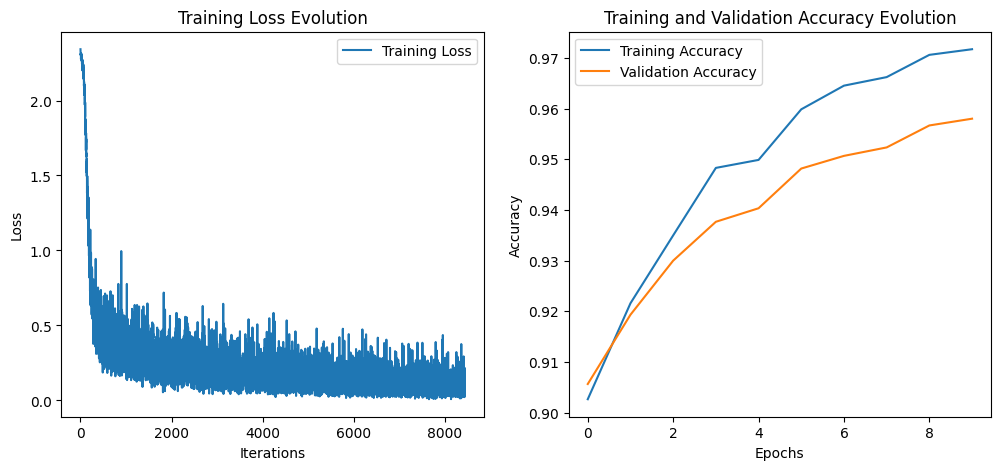

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_list, label='Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss Evolution')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_list, label='Training Accuracy')
plt.plot(val_acc_list, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy Evolution')
plt.legend()
plt.show()


In [8]:
train_acc = compute_accuracy(model, train_loader, device=device)
val_acc   = compute_accuracy(model, val_loader, device=device)
test_acc  = compute_accuracy(model, test_loader, device=device)

print(f"Train Acc {train_acc*100:.2f}%")
print(f"Val Acc {val_acc*100:.2f}%")
print(f"Test Acc {test_acc*100:.2f}%")

Train Acc 97.17%
Val Acc 95.80%
Test Acc 96.48%


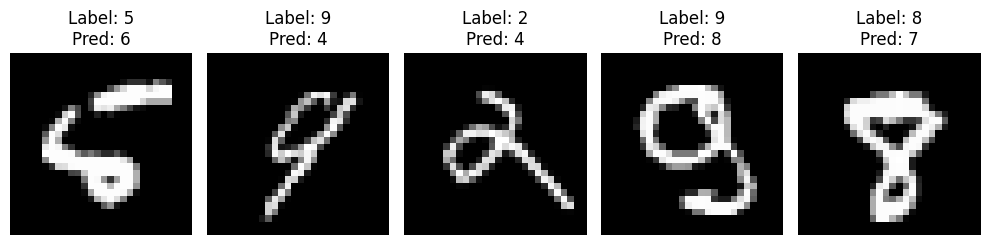

In [9]:
def plot_mistakes(model, test_loader, num_images=5):
    """Plots a specified number of images from the test data where the model made a mistake."""
    model.eval()
    mistakes_images = []
    mistakes_labels = []
    mistakes_predictions = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            logits = model(images)
            predictions = torch.argmax(logits, dim=1)
            incorrect_indices = (predictions != labels)
            if incorrect_indices.any():
                mistakes_images.extend(images[incorrect_indices])
                mistakes_labels.extend(labels[incorrect_indices])
                mistakes_predictions.extend(predictions[incorrect_indices])
            if len(mistakes_images) >= num_images:
                break

    plt.figure(figsize=(10, 5))
    for i in range(min(num_images, len(mistakes_images))):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(mistakes_images[i].squeeze().cpu().numpy(), cmap='gray')
        plt.title(f"Label: {mistakes_labels[i].item()}\nPred: {mistakes_predictions[i].item()}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to plot the mistakes
plot_mistakes(model, test_loader)

## MLP architectures — width vs depth

An **MLP** can have different shapes depending on  
how many hidden layers it includes (*depth*) and how many neurons each layer has (*width*).

It is known that:
- A **wide and shallow** network (one hidden layer with many units) can approximate
  almost any function — this is called the *universal approximation theorem*.
- However, such models:
  - Require many parameters and training data,
  - Are prone to **overfitting**, and
  - Have limited ability to build hierarchical features.

A **narrow and deep** network (several smaller layers):
- Reuses intermediate representations to build more abstract features,
- Usually needs **fewer parameters** to achieve similar accuracy,
- Tends to **generalize better**, though  
  training can be harder due to issues like the *vanishing gradient problem*.

In practice, we often look for a **balance**: a network deep enough to learn structure,
but not so large that it becomes unstable or slow to train.

<img align="center" src="http://www.tsc.uc3m.es/~vanessa/Figs_notebooks/BBVA/GenAI/S1_Fig_8.png" width="60%">

# From manual loops to PyTorch Lightning

In the previous section, we trained our MLP using explicit PyTorch code:
- defined the forward pass,
- computed the loss,
- called `backward()` and `optimizer.step()` in every iteration.

This gives us full control, but as models and experiments become larger, 
manual loops quickly become repetitive and error-prone.

Common issues include:
- repeating almost identical code for **training**, **validation**, and **testing**,  
- difficulty **adding features** (e.g. logging, checkpointing, multi-GPU),  
- lack of a clear, modular **organization** for the project.

---

## Why PyTorch Lightning?

**PyTorch Lightning** is a lightweight wrapper around PyTorch that brings structure and clarity 
to your training code — without hiding the core PyTorch logic.

It separates:
- **Model definition** → what your network does (`forward()`),  
- **Training logic** → how it learns (`training_step()`, `validation_step()`),  
- **Optimization** → how it updates parameters (`configure_optimizers()`).

Everything else (loops, device placement, logging) is handled automatically.

---

We’ll now **rewrite our MLP** inside a `LightningModule`, so we can:
- train with cleaner syntax,  
- automatically log metrics, and  
- prepare the ground for integrating **MLflow** in the next section.

In [10]:
# --- PyTorch Lightning setup (imports only) ---
# If Lightning or torchmetrics are missing in your environment, uncomment the next two lines.
!pip install -q pytorch-lightning torchmetrics

import torch
import torch.nn.functional as F
import pytorch_lightning as pl
from torchmetrics.classification import Accuracy

pl.seed_everything(1)  # reproducibility for Lightning modules and dataloaders

Seed set to 1


1

## Building a LightningModule

We now wrap our MLP inside a `LightningModule`.  
This organizes training, validation, and testing into clear methods:

- `forward`: standard inference  
- `training_step`: one optimization step on a training batch  
- `validation_step`: evaluation on a validation batch  
- `test_step`: evaluation on the test set  
- `configure_optimizers`: define the optimizer (and optionally schedulers)

We’ll also use **TorchMetrics** inside the module to compute accuracy cleanly.

In [11]:
class LitMLP(pl.LightningModule):
    def __init__(self, in_dims=28*28, num_classes=10, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()  # logs hyperparameters automatically
        self.model = PyTorchMLP(in_dims, num_classes)

        # TorchMetrics for accuracy in each phase
        self.train_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.valid_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc  = Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch):
        xs, ys = batch
        logits = self(xs)
        loss = F.cross_entropy(logits, ys)
        preds = torch.argmax(logits, dim=1)
        return loss, preds, ys

    def training_step(self, batch, batch_idx):
        loss, preds, ys = self._shared_step(batch)
        self.log('loss.train', loss, on_epoch=True, on_step=False, prog_bar=True)
        self.train_acc.update(preds, ys)
        self.log('acc.train', self.train_acc, on_epoch=True, on_step=False, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, ys = self._shared_step(batch)
        self.valid_acc.update(preds, ys)
        self.log('loss.val', loss, on_epoch=True, on_step=False, prog_bar=True)
        self.log('acc.val', self.valid_acc, on_epoch=True, on_step=False, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        loss, preds, ys = self._shared_step(batch)
        self.test_acc.update(preds, ys)
        self.log('loss.test', loss, on_epoch=True, on_step=False, prog_bar=True)
        self.log('acc.test',  self.test_acc,  on_epoch=True, on_step=False, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

## The Lightning `Trainer`

The `Trainer` executes the training/validation/test loops for a `LightningModule` and centralizes:

- **Loop orchestration:** runs epochs, batches, and hooks (`training_step`, `validation_step`, `test_step`).
- **Device placement:** moves your module and batches to CPU/GPU automatically—no manual `.to(device)` inside the loop.
- **Precision and performance:** supports mixed precision, gradient accumulation, deterministic runs.
- **Logging:** integrates with Lightning’s logging (`self.log(...)`) and external loggers.

### Core arguments we’ll use first
- `max_epochs`: number of passes over the training set
- `log_every_n_steps`: logging frequency for progress bar/metrics
- `deterministic`: `True` to prefer deterministic algorithms (reproducibility)
- `accelerator`: `"auto"` (or `"gpu"`) for device selection
- `devices`: `"auto"` or an integer (e.g., `1`) for number of devices

We start minimal (clean and reproducible), then extend it when adding MLflow and sweeps.

In [12]:
# --- Train and evaluate the Lightning-wrapped MLP ---

# Hyperparameters for this run (kept simple here; we'll sweep later)
num_epochs = 5
learning_rate = 1e-3

# Instantiate the LightningModule
lit_model = LitMLP(in_dims=28*28, num_classes=10, lr=learning_rate)

# Minimal, reproducible Trainer
trainer = pl.Trainer(
    max_epochs=num_epochs,
    log_every_n_steps=50,
    deterministic=True,     # aim for reproducibility where possible
    accelerator="auto",     # use GPU if available
    devices="auto"
)

# Fit on train/val
trainer.fit(lit_model, train_dataloaders=train_loader, val_dataloaders=val_loader)



💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | PyTorchMLP         | 40.8 K | train
1 | train_acc | MulticlassAccuracy | 0      | train
2 | valid_acc | MulticlassAccuracy | 0      | train
3 | test_acc  | MulticlassAccuracy | 0      | train
---------------------------------------------------------
40.8 K    Trainable params
0         Non-trainable params
40.8 K    Total params
0.163     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:428: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.


/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:428: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


Epoch 4: 100%|██████████| 844/844 [00:10<00:00, 82.49it/s, v_num=0, loss.val=0.152, acc.val=0.955, loss.train=0.126, acc.train=0.963] 

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 844/844 [00:10<00:00, 82.40it/s, v_num=0, loss.val=0.152, acc.val=0.955, loss.train=0.126, acc.train=0.963]


### Evaluating the Lightning model

After fitting, we can evaluate using Lightning’s built-in APIs:

- `trainer.validate(...)` reports the metrics we logged on the **validation set**.
- `trainer.test(...)` reports the logged metrics on the **test set**.

For the **training set**, Lightning doesn’t run a separate “train evaluation” pass by default, so we’ll reuse our plain PyTorch helper `compute_accuracy` as a quick sanity check.

In [13]:
# Lightning-native evaluation
val_metrics  = trainer.validate(lit_model, dataloaders=val_loader)   # logs 'acc.val', 'loss.val'
test_metrics = trainer.test(lit_model,    dataloaders=test_loader)  # logs 'acc.test', 'loss.test'

# Plain PyTorch sanity check on the training set
train_acc = compute_accuracy(lit_model, train_loader)

print(
    f"Train Acc {train_acc*100:.2f}%"
    f" | Val Acc {val_metrics[0].get('acc.val', float('nan'))*100:.2f}%"
    f" | Test Acc {test_metrics[0].get('acc.test', float('nan'))*100:.2f}%"
)

Validation DataLoader 0: 100%|██████████| 94/94 [00:00<00:00, 178.79it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          acc.val          │    0.9551666378974915     │
│         loss.val          │    0.15215052664279938    │
└───────────────────────────┴───────────────────────────┘

/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:428: Consider setting `persistent_workers=True` in 'test_dataloader' to speed up the dataloader worker initialization.


Testing DataLoader 0: 100%|██████████| 157/157 [00:00<00:00, 175.99it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         acc.test          │    0.9610000252723694     │
│         loss.test         │    0.13372525572776794    │
└───────────────────────────┴───────────────────────────┘

Train Acc 96.59% | Val Acc 95.52% | Test Acc 96.10%


## Monitoring with Lightning only: logger + callbacks

Before we bring in any external tracker, Lightning already offers useful monitoring tools:

- **`CSVLogger`**: writes all logged metrics to disk as CSV files (easy to open in any tool).
- **`ModelCheckpoint`**: automatically saves checkpoints during training; we’ll keep the **best** model according to a metric (e.g., validation accuracy).
- **`EarlyStopping`**: stops training if a monitored metric doesn’t improve for a number of validation checks.
- **`LearningRateMonitor`**: records the learning rate over time (handy when using schedulers).

We’ll add these components to the **same `LightningModel`** we trained above, run a short training, and verify:
1) where the **CSV logs** are stored,
2) which **checkpoint** was saved as “best”,
3) how to **reload** that best checkpoint for evaluation.

> This gives us a solid baseline for experiment hygiene *without* any external service. Next, we’ll see how MLflow centralizes the same information across runs.

In [14]:
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
import os

# Reuse the same LightningModule class (LitMLP)
lit_with_callbacks = LitMLP(in_dims=28*28, num_classes=10, lr=1e-3)

# 1) File-based logger (CSV)
csv_logger = CSVLogger(save_dir="lightning_logs", name="mnist_mlp")

# 2) Checkpoint the BEST model by validation accuracy
ckpt_cb = ModelCheckpoint(
    monitor="acc.val",       # <- matches the key logged in validation_step
    mode="max",
    save_top_k=1,
    filename="mlp-{epoch:02d}-{acc.val:.4f}"
)

# 3) Early stopping on validation accuracy
early_cb = EarlyStopping(
    monitor="acc.val",
    mode="max",
    patience=3,
    verbose=True
)

# 4) Record learning rate over time
lr_cb = LearningRateMonitor(logging_interval="epoch")

# Trainer with logger + callbacks
trainer_cb = pl.Trainer(
    max_epochs=6,
    accelerator="auto",
    devices="auto",
    deterministic=True,
    log_every_n_steps=50,
    logger=csv_logger,
    callbacks=[ckpt_cb, early_cb, lr_cb]
)

# Fit the model with native monitoring
trainer_cb.fit(lit_with_callbacks, train_dataloaders=train_loader, val_dataloaders=val_loader)

# Where are things saved?
run_dir = os.path.join(csv_logger.save_dir, csv_logger.name, f"version_{csv_logger.version}")
print("CSV logs directory:", run_dir)
print("Best checkpoint path:", ckpt_cb.best_model_path)
print("Best val_acc:", ckpt_cb.best_model_score.item() if ckpt_cb.best_model_score is not None else None)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | PyTorchMLP         | 40.8 K | train
1 | train_acc | MulticlassAccuracy | 0      | train
2 | valid_acc | MulticlassAccuracy | 0      | train
3 | test_acc  | MulticlassAccuracy | 0      | train
---------------------------------------------------------
40.8 K    Trainable params
0         Non-trainable params
40.8 K    Total params
0.163     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 844/844 [00:10<00:00, 82.86it/s, v_num=0, loss.val=0.264, acc.val=0.929, loss.train=0.475, acc.train=0.866]

Metric acc.val improved. New best score: 0.929


Epoch 1: 100%|██████████| 844/844 [00:10<00:00, 82.71it/s, v_num=0, loss.val=0.202, acc.val=0.942, loss.train=0.218, acc.train=0.936] 

Metric acc.val improved by 0.012 >= min_delta = 0.0. New best score: 0.942


...

Epoch 4: 100%|██████████| 844/844 [00:10<00:00, 82.48it/s, v_num=0, loss.val=0.137, acc.val=0.960, loss.train=0.110, acc.train=0.968] 

Metric acc.val improved by 0.004 >= min_delta = 0.0. New best score: 0.960


Epoch 5: 100%|██████████| 844/844 [00:10<00:00, 82.40it/s, v_num=0, loss.val=0.123, acc.val=0.961, loss.train=0.0944, acc.train=0.972]

Metric acc.val improved by 0.002 >= min_delta = 0.0. New best score: 0.961
`Trainer.fit` stopped: `max_epochs=6` reached.


Epoch 5: 100%|██████████| 844/844 [00:10<00:00, 82.26it/s, v_num=0, loss.val=0.123, acc.val=0.961, loss.train=0.0944, acc.train=0.972]
CSV logs directory: lightning_logs/mnist_mlp/version_0
Best checkpoint path: lightning_logs/mnist_mlp/version_0/checkpoints/mlp-epoch=05-acc.val=0.9612.ckpt
Best val_acc: 0.9611666798591614


In [15]:
# Reload model from the best checkpoint
best_model = LitMLP.load_from_checkpoint(
    ckpt_cb.best_model_path,
    in_dims=28*28,
    num_classes=10,
    lr=1e-3
)

# Evaluate with Lightning-native APIs
val_metrics  = trainer_cb.validate(best_model, dataloaders=val_loader)
test_metrics = trainer_cb.test(best_model,    dataloaders=test_loader)
train_acc    = compute_accuracy(best_model,   train_loader)

print(
    f"Train Acc {train_acc*100:.2f}%"
    f" | Val Acc {val_metrics[0].get('acc.val', float('nan'))*100:.2f}%"
    f" | Test Acc {test_metrics[0].get('acc.test', float('nan'))*100:.2f}%"
)

Validation DataLoader 0: 100%|██████████| 94/94 [00:00<00:00, 182.31it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          acc.val          │    0.9611666798591614     │
│         loss.val          │    0.12334322929382324    │
└───────────────────────────┴───────────────────────────┘

Testing DataLoader 0: 100%|██████████| 157/157 [00:00<00:00, 181.47it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         acc.test          │     0.965399980545044     │
│         loss.test         │    0.1106782853603363     │
└───────────────────────────┴───────────────────────────┘

Train Acc 97.46% | Val Acc 96.12% | Test Acc 96.54%


# From local logs to experiment tracking

So far, PyTorch Lightning already improved our workflow:
- metrics are logged automatically,
- checkpoints and early stopping work out of the box,
- reproducibility is easier to maintain.

However, as soon as we start running **many experiments**, 
local logs quickly become unmanageable:
- dozens of CSV files and checkpoints in different folders,
- no easy way to **compare runs or hyperparameters**,
- difficult to **share or reproduce results** later.

---

## Why bring in MLflow?

**MLflow** is an open-source tool designed for **experiment tracking**.  
It provides a *central hub* where each training run is automatically recorded with:
- its **parameters** (learning rate, batch size, etc.),
- its **metrics** (losses, accuracies),
- its **artifacts** (checkpoints, plots, or any file).

Each run belongs to an **experiment** (for example, `"MNIST"`),  
and you can launch a **local UI** to visualize, sort, and compare results side by side.

---

### What we’ll do next
In the following cells, we will:

1. Configure MLflow with a local tracking URI and create an experiment.  
2. Attach an `MLFlowLogger` to our Lightning `Trainer`.  
3. Enable `mlflow.pytorch.autolog()` to capture metrics and checkpoints automatically.  
4. Re-run our MLP training and explore how metrics and artifacts appear in MLflow’s dashboard.

### MLflow setup: step by step

We’ll:
1) (Optionally) install MLflow,
2) import MLflow and the Lightning logger,
3) configure **where** runs are stored (tracking URI) and **which project** they belong to (experiment),
4) enable **autologging** so Lightning → MLflow happens automatically,
5) re-run a short training with our existing `LightningModel`.

Each step is isolated so you see exactly what it does.

**Install (only if needed)**  
If MLflow or Lightning aren’t available in your environment, uncomment the next cell.  
(We keep installs explicit so the notebook remains portable.)

In [16]:
!pip install -q mlflow pytorch-lightning torchmetrics

**Imports**  
We import MLflow core APIs and the Lightning-side `MLFlowLogger`.

In [17]:
import mlflow
import mlflow.pytorch
from pytorch_lightning.loggers import MLFlowLogger

### Configuring MLflow tracking

MLflow needs to know two things to start tracking experiments:

1. **Tracking URI** — where to store the data.  
   - In this example, we’ll store it locally under `./mlruns`.  
   - In a team setup, this can point to a shared server (e.g., `"http://mlflow.myteam.com"`).

2. **Experiment name** — a logical group of runs.  
   - We’ll name it `"MNIST"` to keep everything organized.

Once configured, MLflow automatically creates the necessary directories or records on the server.

In [18]:
mlflow.set_tracking_uri("file:./mlruns")   # local folder; change to your server URI if needed
mlflow.set_experiment("MNIST")

print("Tracking URI:", mlflow.get_tracking_uri())
print("Current experiment:", mlflow.get_experiment_by_name("MNIST").name)

2025/11/06 17:38:25 INFO mlflow.tracking.fluent: Experiment with name 'MNIST' does not exist. Creating a new experiment.


Tracking URI: file:./mlruns
Current experiment: MNIST


### Connecting MLflow to Lightning

There are two complementary ways MLflow integrates with Lightning:

1. **Autologging (`mlflow.pytorch.autolog`)**  
   - Automatically records model parameters, optimizer info, metrics, and checkpoints.  
   - Works seamlessly with Lightning’s `self.log(...)`.

2. **`MLFlowLogger`**  
   - Attaches to the Lightning `Trainer` so that each call to `trainer.fit(...)` becomes an MLflow **run**.  
   - Handles experiment context and metadata.

Together, these two components ensure that *every metric and artifact* produced during training
appears automatically in MLflow.

In [19]:
# --- Enable autologging ---
mlflow.pytorch.autolog(log_models=True)

# --- Create MLflow logger bound to our "MNIST" experiment ---
mlf_logger = MLFlowLogger(
    experiment_name="MNIST",
    tracking_uri="file:./mlruns"
)

print("MLflow logger initialized.")

MLflow logger initialized.


### Running a tracked experiment

We now reuse our MLP Lightning model but attach the `MLFlowLogger` to the Trainer.

Each training run will:
- create a new **entry** (run) under the `"MNIST"` experiment,
- log all hyperparameters, metrics, and model artifacts automatically.

We’ll run just a few epochs to verify that everything is being captured correctly.

In [20]:
# --- Short run to populate MLflow with one tracked experiment ---

# Define hyperparameters
num_epochs = 3
learning_rate = 0.01
model_name = "MLP"

# Instantiate the Lightning model
lit_mlflow = LitMLP(in_dims=28*28, num_classes=10, lr=learning_rate)

# --- Build a descriptive run name ---
run_name = f"{model_name}_lr{learning_rate}_ep{num_epochs}"

# Create an MLflow logger with that name
mlf_logger = MLFlowLogger(
    experiment_name="MNIST",
    tracking_uri="file:./mlruns",
    run_name=run_name
)

# Trainer configuration (reproducible and minimal)
trainer_mlf = pl.Trainer(
    max_epochs=num_epochs,
    accelerator="auto",
    devices="auto",
    deterministic=True,
    log_every_n_steps=50,
    logger=mlf_logger
)

# --- Train and log everything to MLflow ---
trainer_mlf.fit(lit_mlflow, train_dataloaders=train_loader, val_dataloaders=val_loader)

# Retrieve and print the MLflow run ID (for reference)
run_id = getattr(mlf_logger, "run_id", None)
print(f"MLflow run: {run_name} (run_id={run_id})")

# Optionally log the run_name as a parameter too
if run_id is not None:
    mlf_logger.experiment.log_param(run_id, "run_name", run_name)
    

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
2025/11/06 17:38:25 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '6302d1fbcb734c2a8b7c39d188b2b596', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current pytorch workflow
2025/11/06 17:38:25 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/mlflow/pytorch/_lightning_autolog.py:467: UserWarning: Autologging is known to be compatible with pytorch-lightning versions between 2.0.7 and 2.5.2 and may not succeed with packages outside this range."

  | Name      | Type               | Params 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:428: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.


/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:428: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


Epoch 0: 100%|██████████| 844/844 [00:10<00:00, 83.50it/s, v_num=25e5, loss.val=0.191, acc.val=0.943, loss.train=0.277, acc.train=0.916]

...

Epoch 2: 100%|██████████| 844/844 [00:10<00:00, 81.56it/s, v_num=25e5, loss.val=0.158, acc.val=0.956, loss.train=0.131, acc.train=0.961] 

2025/11/06 17:38:58 WARNING mlflow.utils.checkpoint_utils: Checkpoint logging is skipped, because checkpoint 'save_best_only' config is True, it requires to compare the monitored metric value, but the provided monitored metric value is not available.
`Trainer.fit` stopped: `max_epochs=3` reached.


Epoch 2: 100%|██████████| 844/844 [00:10<00:00, 81.32it/s, v_num=25e5, loss.val=0.158, acc.val=0.956, loss.train=0.131, acc.train=0.961]


2025/11/06 17:39:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


MLflow run: MLP_lr0.01_ep3 (run_id=371bc2f682fb4602a39ef036ba8125e5)


### Exploring the results in MLflow

All runs are now stored under the folder `./mlruns` (since we used a local tracking URI).

If you have access to a shell, you can launch the MLflow UI with:

```bash
mlflow ui --backend-store-uri ./mlruns
```

### Understanding the MLflow Experiment Structure

When you run experiments with MLflow, each call to `Trainer.fit()` creates a **run** inside an **experiment**.

Let’s break down what’s happening behind the scenes so you can interpret what you see in the UI or in the `./mlruns` folder.

---

#### Experiment level
An **experiment** is a logical container for related runs.  
Here we called:
```python
mlflow.set_experiment("MNIST")
```

which created a folder structure like:

```bash
mlruns/
└── 1234567890/          ← experiment ID
    ├── meta.yaml         (metadata about the experiment)
    ├── MLP_lr0.01_ep3/     ← one run (MLP baseline)
    └── MLP_lr0.01_ep5/    ← another run
```

**Run level**
Each run represents one complete training execution (e.g., one `Lightning Trainer.fit()`).

Inside every run folder you’ll find:

```bash
meta.yaml         ← run metadata (start/end time, user, etc.)
params/           ← hyperparameters (learning_rate, batch_size, etc.)
metrics/          ← logged metrics (loss, accuracy, val_acc, …)
artifacts/        ← saved files: model checkpoints, plots, etc.
tags/             ← additional labels or notes
```

#### In the MLflow UI

In the MLflow UI, these appear as columns:

| **Field**   | **Meaning**                                                         |
|-------------|----------------------------------------------------------------------|
| **Run Name**| Now defined by us (e.g., MLP_lr0.01_ep3, CNN_lr0.001_ep5) for easy identification                 |
| **Params**  | All hyperparameters logged for this run                              |
| **Metrics** | Numeric results logged during training                               |
| **Artifacts** | Stored files (model weights, images, confusion matrices, …)       |
| **Source**  | Where the run was launched (e.g., Jupyter kernel)                    |

#### Navigating the UI

- Click a run name to **see details**: parameters, metric curves, and stored artifacts.  
- You can **compare multiple runs** by checking them and clicking *Compare*.  
- Click on a metric name (e.g. `val_acc`) to plot its evolution across epochs.  
- Artifacts such as saved models or custom plots appear under the *Artifacts* tab.

---

#### Tip

Everything MLflow tracks is stored locally under the folder you specified in:

```python
mlflow.set_tracking_uri("file:./mlruns")
```

So even without the UI, you can inspect or back up your results directly from that folder.



### Logging custom artifacts

Autologging already captures parameters, metrics, and checkpoints.  
But sometimes we want to attach **extra files** to a run, such as:

- a **confusion matrix** plot,
- sample predictions,
- diagnostic figures,
- even whole datasets.

These are logged with `mlflow.log_artifact(file_path)`.

Next, we’ll generate a confusion matrix for our MLP on the test set, save it as a PNG, and log it to MLflow.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import os

# Get predictions on the test set
lit_mlflow.eval()
all_preds, all_labels = [], []
for features, labels in test_loader:
    features, labels = features.to(device), labels.to(device)
    with torch.no_grad():
        logits = lit_mlflow(features)
    preds = torch.argmax(logits, dim=1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
classes = list(range(10))

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (MLP on MNIST)")

# Use the MLflow run name (if available) to make filenames unique
run_name = getattr(mlf_logger, "run_name", "unnamed_run")
cm_path = f"confusion_matrix_{run_name}.png"

# Save figure locally
plt.savefig(cm_path, bbox_inches="tight")
plt.close()

# Log figure as an artifact in MLflow
mlflow.log_artifact(cm_path, artifact_path="figures")

print(f"Logged confusion matrix to MLflow: {cm_path}")

Logged confusion matrix to MLflow: confusion_matrix_unnamed_run.png


## Recap: Experiment tracking with MLflow

So far, we have learned how to:

- **Attach MLflow to Lightning** using `MLFlowLogger`.
- **Enable autologging** with `mlflow.pytorch.autolog(...)` so that:
  - hyperparameters are automatically stored,
  - metrics from `self.log(...)` are captured,
  - checkpoints and models are logged as artifacts.
- **Log custom artifacts** (e.g., confusion matrix PNGs) using `mlflow.log_artifact(...)`.

Together, this gives us a **structured record of each run**:
- **Parameters** → searchable and comparable.  
- **Metrics** → visualized per epoch and across runs.  
- **Artifacts** → reproducible checkpoints and diagnostic plots.

In this session, we also incorporated several **good practices** for experiment organization:

- **Tracking URI and Experiment:**  
  Explicitly configured at the start with  
  `mlflow.set_tracking_uri("file:./mlruns")` and `mlflow.set_experiment("MNIST")`.

- **Run naming and tags** (optional but highly recommended):  
  When creating the `MLFlowLogger`, we assign a descriptive name to each run (e.g., model type + key hyperparameters)  
  and can add **tags** using `mlflow.set_tags(...)` or `mlf_logger.experiment.set_tag(...)`.  
  This makes filtering and comparison in the MLflow UI much easier.

- **Visualizing results in the UI:**  
  Within the experiment view, you can:
  - Sort runs by final metrics (e.g., `val_acc_final`, `test_acc_final`),
  - Use **Parallel Coordinates** plots to see how hyperparameters affect accuracy,
  - Open **Metrics** to compare learning curves (e.g., validation accuracy) across multiple runs,
  - Inspect or download **artifacts** such as saved models or plots.

**Result:**  
A scalable, reproducible workflow that replaces scattered CSVs with clean, centralized experiment tracking.

---

**Next step:**  
We’ll move beyond single runs and learn how to launch and track **hyperparameter sweeps** in MLflow —  
first using a simple grid or random search loop, and later with tools like Optuna for more advanced optimization.

## Hyperparameter sweeps (grid/random only)

We’ll run a **small sweep** by trying several configurations and logging each **trial as an MLflow run**.  
This is enough to compare settings like learning rate, batch size, and optimizer without adding new libraries.

### What we’ll build
- A tiny **search space** (e.g., two learning rates × two batch sizes × two optimizers).
- A helper that **trains one run** (short training) and returns final metrics.
- A loop that **iterates over configs** (grid or random sample), logs to MLflow, and prints a compact summary.

We keep each run short (few epochs) so the whole sweep is easy to follow and fast to execute.

In [22]:
# --- Sweep setup: define a tiny search space + helpers (no training yet) ---

from itertools import product
import pytorch_lightning as pl

# Reproducibility for all trials launched from this notebook
pl.seed_everything(1, workers=True)

# Small grid we can expand later
SEARCH_SPACE = {
    "learning_rate": [1e-2, 1e-3],
    "batch_size":    [64, 128],
    "optimizer":     ["sgd", "adam"],
    "max_epochs":    [3],      # short runs to keep the sweep quick
    "model": ["mlp"]
    # Optional future-proofing:
    # "model": ["mlp", "cnn"]  # use if you want to sweep architectures
}

def iter_grid(space):
    """Cartesian product over a dict of lists -> yields config dicts."""
    keys = list(space.keys())
    for values in product(*(space[k] for k in keys)):
        yield dict(zip(keys, values))

def grid_size(space):
    """Number of combinations without materializing them."""
    n = 1
    for k in space:
        n *= len(space[k])
    return n

def run_name_from_config(cfg, prefix="MNIST"):
    """
    Build a readable MLflow run name from a config.
    Example: 'MNIST-lr=0.01-bs=64-opt=sgd-ep=3'
    """
    parts = [
        f"lr={cfg['learning_rate']}",
        f"bs={cfg['batch_size']}",
        f"opt={cfg['optimizer']}",
        f"ep={cfg['max_epochs']}",
    ]
    # If you add 'model' to SEARCH_SPACE later, uncomment:
    if 'model' in cfg: parts.insert(0, f"model={cfg['model']}")
    return f"{prefix}-" + "-".join(parts)

def run_trial(config):
    """
    Train one trial with the given config and log it to MLflow.

    Expected keys in `config`:
      - learning_rate (float)
      - batch_size (int)
      - optimizer ("sgd" or "adam")
      - max_epochs (int)

    Returns:
      dict with summary metrics (e.g., {"val_acc": ..., "test_acc": ...})

    """
    pass

# Example: preview a few configs (no training yet)
print(f"Total trials planned: {grid_size(SEARCH_SPACE)}")
for i, cfg in zip(range(3), iter_grid(SEARCH_SPACE)):
    print(run_name_from_config(cfg), "->", cfg)

Seed set to 1


Total trials planned: 8
MNIST-model=mlp-lr=0.01-bs=64-opt=sgd-ep=3 -> {'learning_rate': 0.01, 'batch_size': 64, 'optimizer': 'sgd', 'max_epochs': 3, 'model': 'mlp'}
MNIST-model=mlp-lr=0.01-bs=64-opt=adam-ep=3 -> {'learning_rate': 0.01, 'batch_size': 64, 'optimizer': 'adam', 'max_epochs': 3, 'model': 'mlp'}
MNIST-model=mlp-lr=0.01-bs=128-opt=sgd-ep=3 -> {'learning_rate': 0.01, 'batch_size': 128, 'optimizer': 'sgd', 'max_epochs': 3, 'model': 'mlp'}


### Extending the Lightning module for sweeps

Our sweep will try different **optimizers** (SGD vs Adam).  
To support this, we add a small hyperparameter (`optimizer`) to the `LightningModel` and switch inside `configure_optimizers`.

In [23]:
class LightningModel(pl.LightningModule):
    def __init__(self, model, learning_rate=0.05, num_classes=10, optimizer="sgd"):
        super().__init__()
        # Save hparams so MLflow autolog & Lightning log them (exclude the model object)
        self.save_hyperparameters(ignore=["model"])
        self.model = model
        self.optimizer_name = str(optimizer).lower()

        # Metrics per split (same objects/names we used before)
        self.train_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc   = Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc  = Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch):
        features, true_labels = batch
        logits = self(features)
        loss = F.cross_entropy(logits, true_labels)
        predicted_labels = torch.argmax(logits, dim=1)
        return loss, true_labels, predicted_labels

    def training_step(self, batch, batch_idx):
        loss, y_true, y_pred = self._shared_step(batch)
        self.log("train_loss", loss)  # same key as before
        self.train_acc(y_pred, y_true)
        # epoch-level logging (clean progress bar), same as earlier section
        self.log("train_acc", self.train_acc, prog_bar=True, on_epoch=True, on_step=False)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, y_true, y_pred = self._shared_step(batch)
        self.log("val_loss", loss, prog_bar=True)  # same key as before
        self.val_acc(y_pred, y_true)
        self.log("val_acc", self.val_acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        loss, y_true, y_pred = self._shared_step(batch)
        self.test_acc(y_pred, y_true)
        # keep single test key "accuracy" to match previous prints
        self.log("accuracy", self.test_acc)

    def configure_optimizers(self):
        lr = float(self.hparams.learning_rate)
        if self.optimizer_name == "adam":
            return torch.optim.Adam(self.parameters(), lr=lr)
        if self.optimizer_name == "sgd":
            return torch.optim.SGD(self.parameters(), lr=lr)
        raise ValueError(f"Unsupported optimizer: {self.optimizer_name}")

### The `run_trial(config)` helper

This function executes **one complete training run** for a given configuration and logs it to MLflow.

**Workflow:**

1. **Create dataloaders** using the specified `batch_size`.  
2. **Instantiate the model** with the chosen `learning_rate` and `optimizer`.  
3. **Attach an MLflow logger** (`MLFlowLogger`) with a descriptive run name built from the config.  
4. **Train briefly** for `max_epochs` epochs to keep the sweep lightweight.  
5. **Evaluate** on both validation and test sets using `trainer.test(...)`.  
6. **Log summary metrics and hyperparameters** (e.g., `val_acc_final`, `test_acc_final`, `batch_size`, etc.) to MLflow.  
7. **Return** a concise summary dictionary containing metrics and identifiers for later aggregation.

The function is fully self-contained so that the sweep loop can call it repeatedly with different parameter configurations.

In [24]:
from pytorch_lightning.loggers import MLFlowLogger

def run_trial(config):
    """
    Train one trial with the given config and log it to MLflow.

    Expected keys in `config`:
      - learning_rate (float)
      - batch_size (int)
      - optimizer ("sgd" or "adam")
      - max_epochs (int)
      - model (optional, "mlp" [default])

    Returns:
      dict with summary metrics and identifiers:
      {
        "run_id": str or None,
        "val_acc": float,
        "test_acc": float,
        "config": dict
      }
    """
    # 1) Create dataloaders for this configuration
    train_loader_t, val_loader_t, test_loader_t = get_mnist_loaders(
        batch_size=int(config["batch_size"]), val_ratio=0.1, root_dir="./data"
    )

    # 2) Select the model (MLP by default)
    model_choice = config.get("model", "mlp").lower()
    if model_choice == "mlp":
        backbone = PyTorchMLP(num_features=28*28, num_classes=10)
    else:
        raise ValueError(f"Unsupported model: {model_choice}")

    trial_model = LightningModel(
        model=backbone,
        learning_rate=float(config["learning_rate"]),
        num_classes=10,
        optimizer=config["optimizer"]
    )

    # 3) Create an MLflow logger with a descriptive run name
    run_name = run_name_from_config(config, prefix="MNIST")
    mlf_logger = MLFlowLogger(
        experiment_name="MNIST",
        tracking_uri="file:./mlruns",
        run_name=run_name
    )

    # 4) Train the model briefly
    trainer_trial = pl.Trainer(
        max_epochs=int(config["max_epochs"]),
        accelerator="auto",
        devices="auto",
        deterministic=True,
        log_every_n_steps=50,
        logger=mlf_logger
    )
    trainer_trial.fit(trial_model, train_dataloaders=train_loader_t, val_dataloaders=val_loader_t)

    # 5) Evaluate on validation and test sets
    val_metrics  = trainer_trial.test(trial_model, dataloaders=val_loader_t)[0]
    test_metrics = trainer_trial.test(trial_model, dataloaders=test_loader_t)[0]

    val_acc  = float(val_metrics.get("accuracy", float("nan")))
    test_acc = float(test_metrics.get("accuracy", float("nan")))

    # 6) Return concise summary for the sweep
    run_id = getattr(mlf_logger, "run_id", None)
    return {
        "run_id": run_id,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "config": dict(config),
    }

### Running the sweep

We now loop over all configurations in our tiny search space:

- Each trial is launched with `run_trial(config)`.  
- MLflow logs parameters, metrics, and artifacts as usual.  
- We also collect a **summary dictionary** in Python so we can print a quick table at the end.

In [25]:
summaries = []

# Precompute total once (avoids rebuilding the grid each iteration)
total = grid_size(SEARCH_SPACE)

for i, cfg in enumerate(iter_grid(SEARCH_SPACE), start=1):
    run_name = run_name_from_config(cfg, prefix="MNIST")
    print(f"\n=== Trial {i} / {total} ===")
    print(run_name, "->", cfg)

    summary = run_trial(cfg)
    summaries.append(summary)

# Compact summary table
print("\nSweep results:")
for s in summaries:
    cfg = s["config"]
    rid = s.get("run_id", "N/A")
    print(
        f"model={cfg.get('model','mlp'):<4} | "
        f"LR={cfg['learning_rate']:<6} | BS={cfg['batch_size']:<3} | OPT={cfg['optimizer']:<4} "
        f"| val_acc={s['val_acc']*100:5.2f}% | test_acc={s['test_acc']*100:5.2f}% "
        f"| run_id={rid}"
    )

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
2025/11/06 17:39:06 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/mlflow/pytorch/_lightning_autolog.py:467: UserWarning: Autologging is known to be compatible with pytorch-lightning versions between 2.0.7 and 2.5.2 and may not succeed with packages outside this range."

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | PyTorchMLP         | 40.8 K | train
1 | train_acc | MulticlassAccuracy | 0      | train
2 | val_acc   | MulticlassAccuracy | 0      | train
3 | test_acc  | MulticlassAccuracy | 0 


=== Trial 1 / 8 ===
MNIST-model=mlp-lr=0.01-bs=64-opt=sgd-ep=3 -> {'learning_rate': 0.01, 'batch_size': 64, 'optimizer': 'sgd', 'max_epochs': 3, 'model': 'mlp'}
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:428: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.


/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:428: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


Epoch 2: 100%|██████████| 844/844 [00:12<00:00, 70.11it/s, v_num=c8a2, val_loss=0.413, val_acc=0.882, train_acc=0.869]

...

Testing DataLoader 0: 100%|██████████| 47/47 [00:00<00:00, 149.70it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         accuracy          │    0.9483333230018616     │
└───────────────────────────┴───────────────────────────┘

Testing DataLoader 0: 100%|██████████| 79/79 [00:00<00:00, 143.77it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         accuracy          │    0.9477999806404114     │
└───────────────────────────┴───────────────────────────┘


Sweep results:
model=mlp  | LR=0.01   | BS=64  | OPT=sgd  | val_acc=88.20% | test_acc=88.06% | run_id=dcbe6a1ac9ba4966b00d164ca9bec8a2
model=mlp  | LR=0.01   | BS=64  | OPT=adam | val_acc=94.90% | test_acc=95.32% | run_id=1c9fb72b550a44e3977bff5cd5e899f6
model=mlp  | LR=0.01   | BS=128 | OPT=sgd  | val_acc=78.70% | test_acc=80.10% | run_id=9f1d9aef8fb246cfb07dbb648ed8bdc5
model=mlp  | LR=0.01   | BS=128 | OPT=adam | val_acc=96.18% | test_acc=96.21% | run_id=59b344330bc244fa978fea4a034dce09
model=mlp  | LR=0.001  | BS=64  | OPT=sgd  | val_acc=25.55% | test_acc=25.32% | run_id=9e4fd55362fc4f4c9d1374561459520e
model=mlp  | LR=0.001  | BS=64  | OPT=adam | val_acc=95.07% | test_acc=95.48% | run_id=f3a5c0d6284b4b70b223d7203380a783
model=mlp  | LR=0.001  | BS=128 | OPT=sgd  | val_acc=23.13% | test_acc=24.56% | run_id=08db9120feb348c5bef347b066e51c0a
model=mlp  | LR=0.001  | BS=128 | OPT=adam | val_acc=94.83% | test_acc=94.78% | run_id=804741fd56444d81afc9de4a903e7559


## Visualizing sweeps in MLflow

Once the sweep has logged multiple runs, the MLflow UI lets us explore them:

1. **Start the UI locally**:

```bash
mlflow ui --backend-store-uri ./mlruns
```
Then open [http://127.0.0.1:5000](http://127.0.0.1:5000) in your browser.

2. **Experiment view**:
- See all runs listed with their `run_id`, parameters, and metrics.
- Sort by columns (e.g., highest `val_acc_final`).

3. **Parallel coordinates plot**:
- Visualize how hyperparameters (learning rate, batch size, optimizer) relate to validation/test accuracy.

4. **Metric curves**:
- Inspect training/validation loss and accuracy across epochs.
- Compare curves from different runs.

5. **Artifacts tab**:
- Access model checkpoints.
- See diagnostic plots (e.g., the confusion matrix we logged).

This turns the raw logs into an **interactive dashboard** where you can filter, compare, and select the best configuration at a glance.

## Recap: hyperparameter sweeps

In this section we:

- Defined a **search space** of hyperparameters (learning rate, batch size, optimizer).
- Wrote a helper `run_trial(config)` that:
  - builds loaders and a model for that config,
  - attaches MLflow logging,
  - trains and evaluates briefly,
  - logs summary metrics.
- Launched a **grid sweep**, where each trial became an MLflow run with its own parameters, metrics, and artifacts.

This already gives us a clear view of how hyperparameters affect results, and MLflow makes it easy to compare runs side by side.

---

### Beyond this notebook: Optuna
For larger sweeps, instead of grid/random search you can use **Optuna**, a library for *automated hyperparameter optimization*.  

- Optuna chooses hyperparameters adaptively (e.g., Bayesian optimization, TPE).  
- It integrates with MLflow via a callback: each Optuna trial can log to MLflow just like our manual runs.  
- Requires an extra install: `pip install optuna`.  
- You define an `objective(trial)` function instead of a fixed grid.  

Optuna is powerful for research or production, but for our teaching purposes the **manual sweep** already illustrates the key ideas without extra complexity.

# Wrap-up: Part II — Engineering workflow

In this session we learned about the MLP and how to move from *one-off training scripts* to a more structured and trackable workflow.

### Key takeaways

- **PyTorch Lightning**
  - Organizes training code cleanly with `LightningModule`.
  - Centralizes loops, logging, device management, and callbacks.
  - Already provides CSV logging, checkpointing, early stopping, and reproducibility.

- **MLflow tracking**
  - Collects all runs under a named experiment and runs.
  - Logs parameters, metrics, and artifacts (checkpoints, plots, confusion matrices).
  - Makes it easy to compare runs side by side.

- **Hyperparameter sweeps**
  - Simple grid/random sweeps turn into multiple MLflow runs automatically.
  - Each run keeps its own parameters, metrics, and artifacts.
  - Beyond this notebook: Optuna provides adaptive, more efficient sweeps when search spaces get larger.

---

With this workflow, you can **reproduce, monitor, and optimize experiments** — crucial for applied projects and collaborations.

In **Part III**, we will build on this and learn about **CNNs** and explore **pretrained models and finetuning**, applying these engineering practices to more powerful architectures.